In [195]:
# options(timeout = 300)
# install.packages("glue")
# install.packages("dplyr")

In [196]:
library(glue)
library(dplyr)
library(ggplot2)

### 2.1.3. Предварительная обработка данных (заполнение пропусков, фильтрация, преобразование).

In [197]:
df <- read.csv('data/Sleep_health_and_lifestyle_dataset.csv')
head(df)

,Person.ID,Gender,Age,Occupation,Sleep.Duration,Quality.of.Sleep,Physical.Activity.Level,Stress.Level,BMI.Category,Blood.Pressure,Heart.Rate,Daily.Steps,Sleep.Disorder
,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia


In [198]:
str(df)

'data.frame':	374 obs. of  13 variables:
 $ Person.ID              : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender                 : chr  "Male" "Male" "Male" "Male" ...
 $ Age                    : int  27 28 28 28 28 28 29 29 29 29 ...
 $ Occupation             : chr  "Software Engineer" "Doctor" "Doctor" "Sales Representative" ...
 $ Sleep.Duration         : num  6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 ...
 $ Quality.of.Sleep       : int  6 6 6 4 4 4 6 7 7 7 ...
 $ Physical.Activity.Level: int  42 60 60 30 30 30 40 75 75 75 ...
 $ Stress.Level           : int  6 8 8 8 8 8 7 6 6 6 ...
 $ BMI.Category           : chr  "Overweight" "Normal" "Normal" "Obese" ...
 $ Blood.Pressure         : chr  "126/83" "125/80" "125/80" "140/90" ...
 $ Heart.Rate             : int  77 75 75 85 85 85 82 70 70 70 ...
 $ Daily.Steps            : int  4200 10000 10000 3000 3000 3000 3500 8000 8000 8000 ...
 $ Sleep.Disorder         : chr  "None" "None" "None" "Sleep Apnea" ...


In [199]:
colSums(is.na(df))

Person.ID                  Gender                     Age 
                      0                       0                       0 
             Occupation          Sleep.Duration        Quality.of.Sleep 
                      0                       0                       0 
Physical.Activity.Level            Stress.Level            BMI.Category 
                      0                       0                       0 
         Blood.Pressure              Heart.Rate             Daily.Steps 
                      0                       0                       0 
         Sleep.Disorder 
                      0

Пропусков не обнаружено

In [200]:
string_columns <- c('Gender', 'Occupation', 'BMI.Category', 'Blood.Pressure', 'Sleep.Disorder')
for (col in string_columns) {
    output <- paste(unique(df[[col]]), collapse = ', ')
    print(glue('Столбец {col}: {output}'))
}


Столбец Gender: Male, Female
Столбец Occupation: Software Engineer, Doctor, Sales Representative, Teacher, Nurse, Engineer, Accountant, Scientist, Lawyer, Salesperson, Manager
Столбец BMI.Category: Overweight, Normal, Obese, Normal Weight
Столбец Blood.Pressure: 126/83, 125/80, 140/90, 120/80, 132/87, 130/86, 117/76, 118/76, 128/85, 131/86, 128/84, 115/75, 135/88, 129/84, 130/85, 115/78, 119/77, 121/79, 125/82, 135/90, 122/80, 142/92, 140/95, 139/91, 118/75
Столбец Sleep.Disorder: None, Sleep Apnea, Insomnia


Occupation - много.выбрать в категории \
BMI.Category - дубликат \
Blood.Pressure в число и группы (потом)

In [201]:
df$BMI.Category <- recode(df$BMI.Category, 'Normal Weight' = 'Normal')

In [202]:
df$Occupation.Category <- df$Occupation

df$Occupation.Category[df$Occupation.Category %in% c("Nurse", "Doctor")] <- 'Healthcare'
df$Occupation.Category[df$Occupation.Category %in% c("Software Engineer", "Engineer", "Scientist", "Accountant")] <- 'Office'
df$Occupation.Category[df$Occupation.Category %in% c('Salesperson', 'Sales Representative', 'Manager', 'Lawyer', 'Teacher')] <- 'Social'

In [203]:
splitted_blood_pressure <- strsplit(df$Blood.Pressure, '/')
df$Systolic <- as.numeric(sapply(splitted_blood_pressure, '[', 1))
df$Diastolic <- as.numeric(sapply(splitted_blood_pressure, '[', 2))

In [204]:
str(df)

'data.frame':	374 obs. of  16 variables:
 $ Person.ID              : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender                 : chr  "Male" "Male" "Male" "Male" ...
 $ Age                    : int  27 28 28 28 28 28 29 29 29 29 ...
 $ Occupation             : chr  "Software Engineer" "Doctor" "Doctor" "Sales Representative" ...
 $ Sleep.Duration         : num  6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 ...
 $ Quality.of.Sleep       : int  6 6 6 4 4 4 6 7 7 7 ...
 $ Physical.Activity.Level: int  42 60 60 30 30 30 40 75 75 75 ...
 $ Stress.Level           : int  6 8 8 8 8 8 7 6 6 6 ...
 $ BMI.Category           : chr  "Overweight" "Normal" "Normal" "Obese" ...
 $ Blood.Pressure         : chr  "126/83" "125/80" "125/80" "140/90" ...
 $ Heart.Rate             : int  77 75 75 85 85 85 82 70 70 70 ...
 $ Daily.Steps            : int  4200 10000 10000 3000 3000 3000 3500 8000 8000 8000 ...
 $ Sleep.Disorder         : chr  "None" "None" "None" "Sleep Apnea" ...
 $ Occupation.Category    : chr  "Of

## 2.2. Исследовательский анализ данных (EDA– Exploratory Data Analysis)

### 2.2.1. Визуализация распределений (гистограммы, боксплоты, диаграммы рассеяния).

In [205]:
options(repr.plot.width = 12, repr.plot.height = 6)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


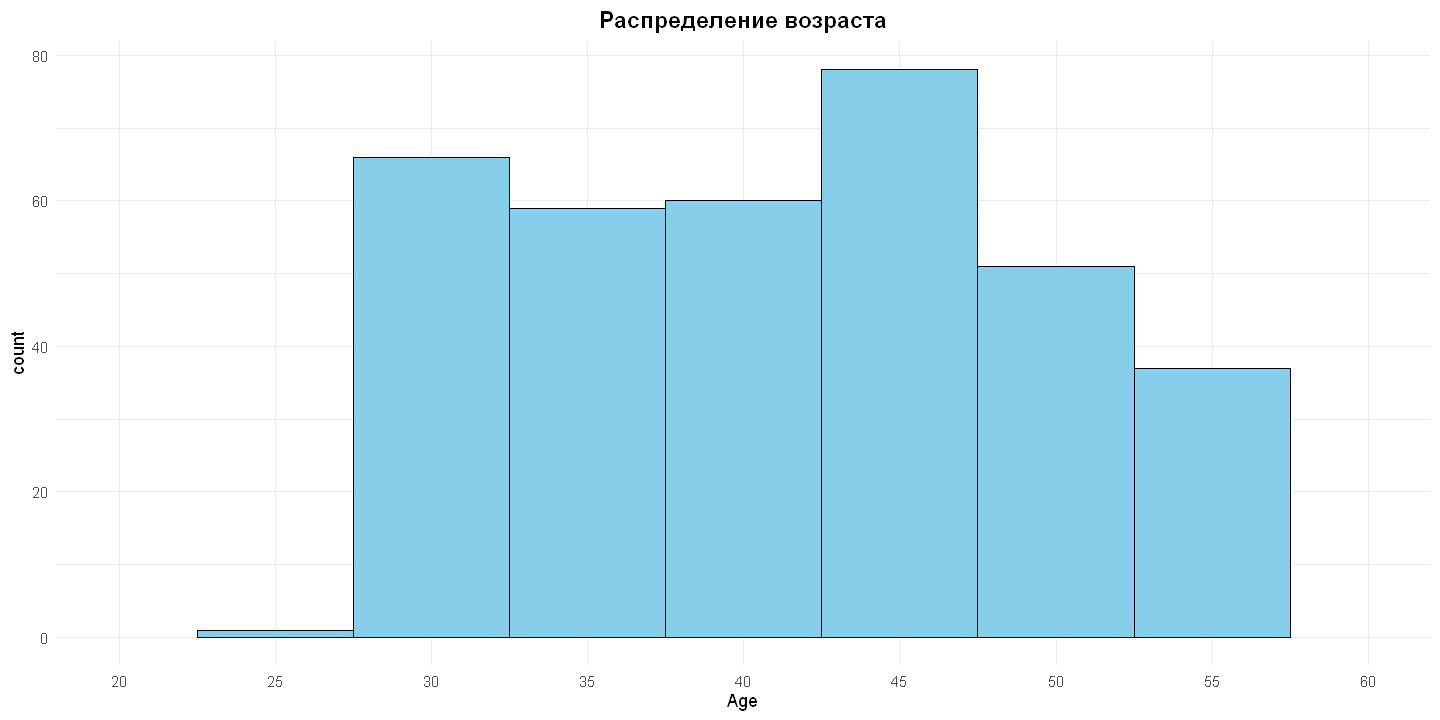

In [206]:
ggplot(df, aes(x = Age)) + 
  geom_histogram(binwidth = 5, fill = "skyblue", color = "black") +
  theme_minimal() + 
  scale_x_continuous( limits = c(20, 60), breaks = seq(20, 60, by = 5)) +
  labs(title = "Распределение возраста") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank(),
  )
  
ggsave("materials/histogram/age_histogram.png", width = 12, height = 6, dpi = 300)

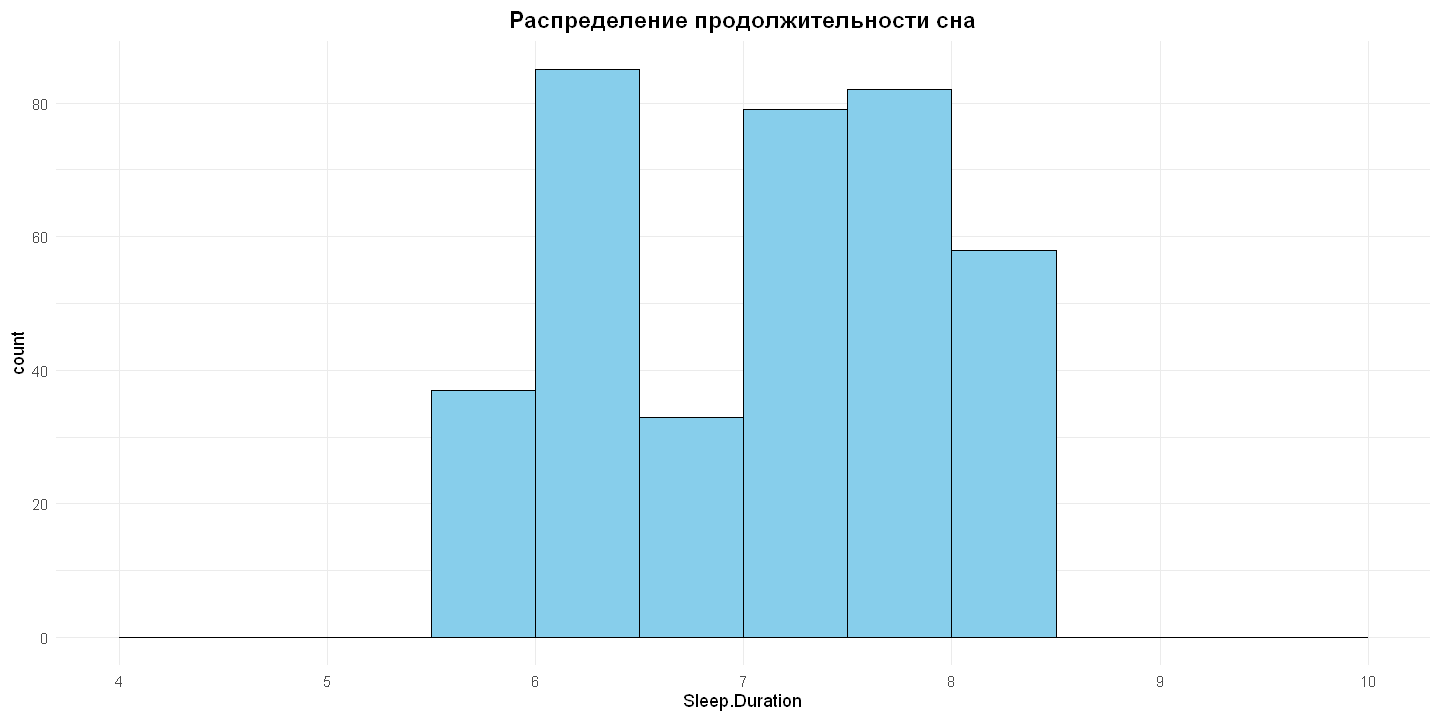

In [207]:
ggplot(df, aes(x = Sleep.Duration)) + 
  geom_histogram(binwidth = 0.5, fill = "skyblue", color = "black", boundary = 0) +
  theme_minimal() + 
  scale_x_continuous( limits = c(4, 10), breaks = 0:10) +
  labs(title = "Распределение продолжительности сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank()
  )
  
ggsave("materials/histogram/sleep_duration_histogram.png", width = 12, height = 6, dpi = 300)

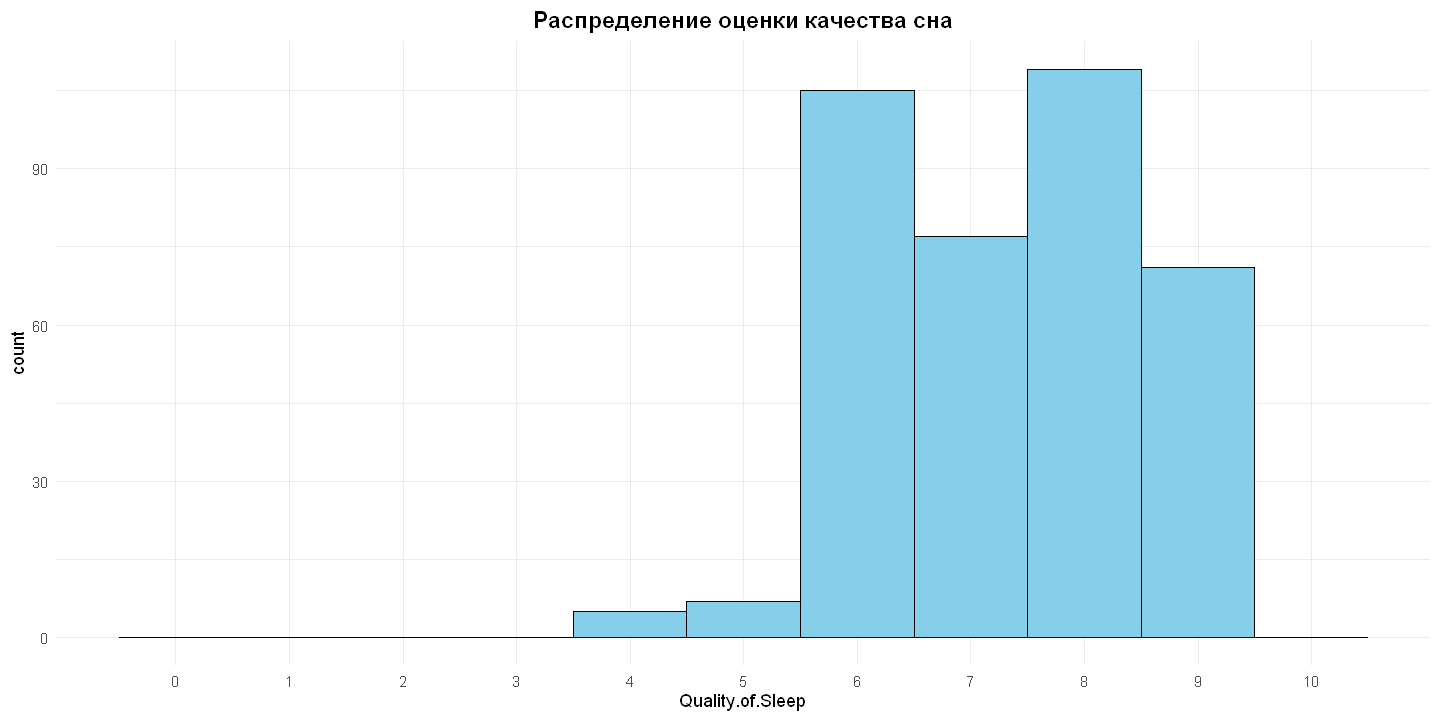

In [208]:
ggplot(df, aes(x = Quality.of.Sleep)) + 
  geom_histogram(binwidth = 1, fill = "skyblue", color = "black", boundary = 0.5) +
  theme_minimal() + 
  scale_x_continuous( limits = c(-0.5, 10.5), breaks = 0:10) +
  labs(title = "Распределение оценки качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank(),
  )
  
ggsave("materials/histogram/quality_of_sleep_histogram.png", width = 12, height = 6, dpi = 300)

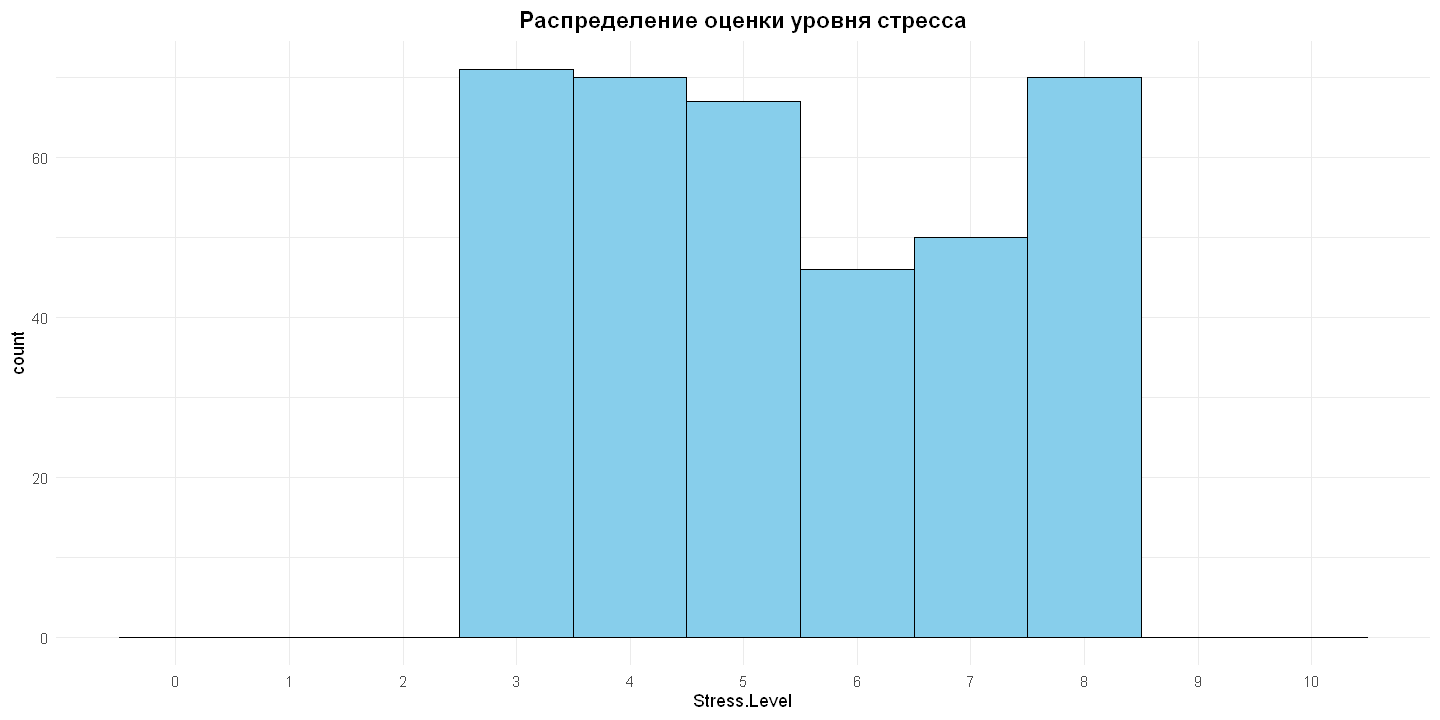

In [209]:
ggplot(df, aes(x = Stress.Level)) + 
  geom_histogram(binwidth = 1, fill = "skyblue", color = "black", boundary = 0.5) +
  theme_minimal() + 
  scale_x_continuous( limits = c(-0.5, 10.5), breaks = 0:10) +
  labs(title = "Распределение оценки уровня стресса") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank(),
  )
  
ggsave("materials/histogram/stress_level_histogram.png", width = 12, height = 6, dpi = 300)

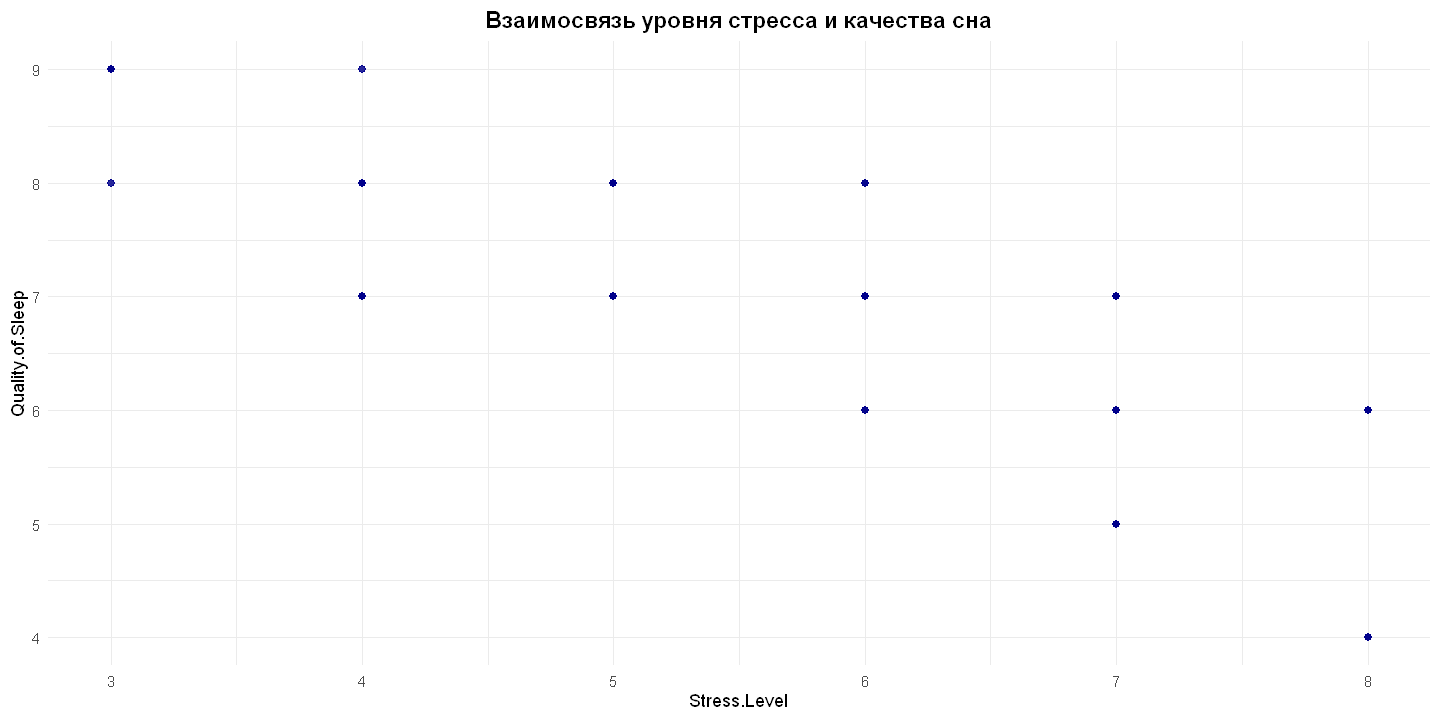

In [210]:
ggplot(df, aes(x = Stress.Level, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  theme_minimal() +
  labs(title = "Взаимосвязь уровня стресса и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

ggsave("materials/scatterplot/stress_level_quality_of_sleep_scatterplot.png", width = 12, height = 6, dpi = 300)

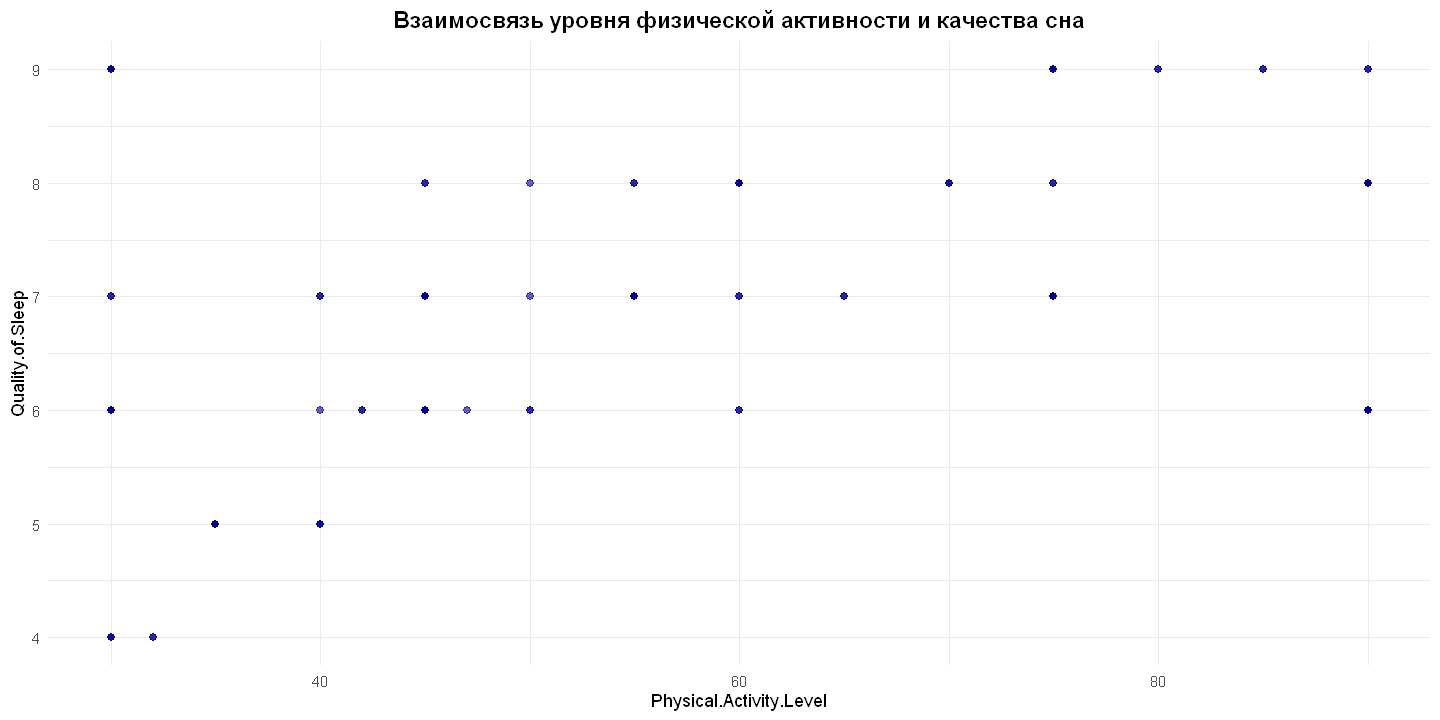

In [211]:
ggplot(df, aes(x = Physical.Activity.Level, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  theme_minimal() +
  labs(title = "Взаимосвязь уровня физической активности и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

ggsave("materials/scatterplot/physical_activity_level_quality_of_sleep_scatterplot.png", width = 12, height = 6, dpi = 300)

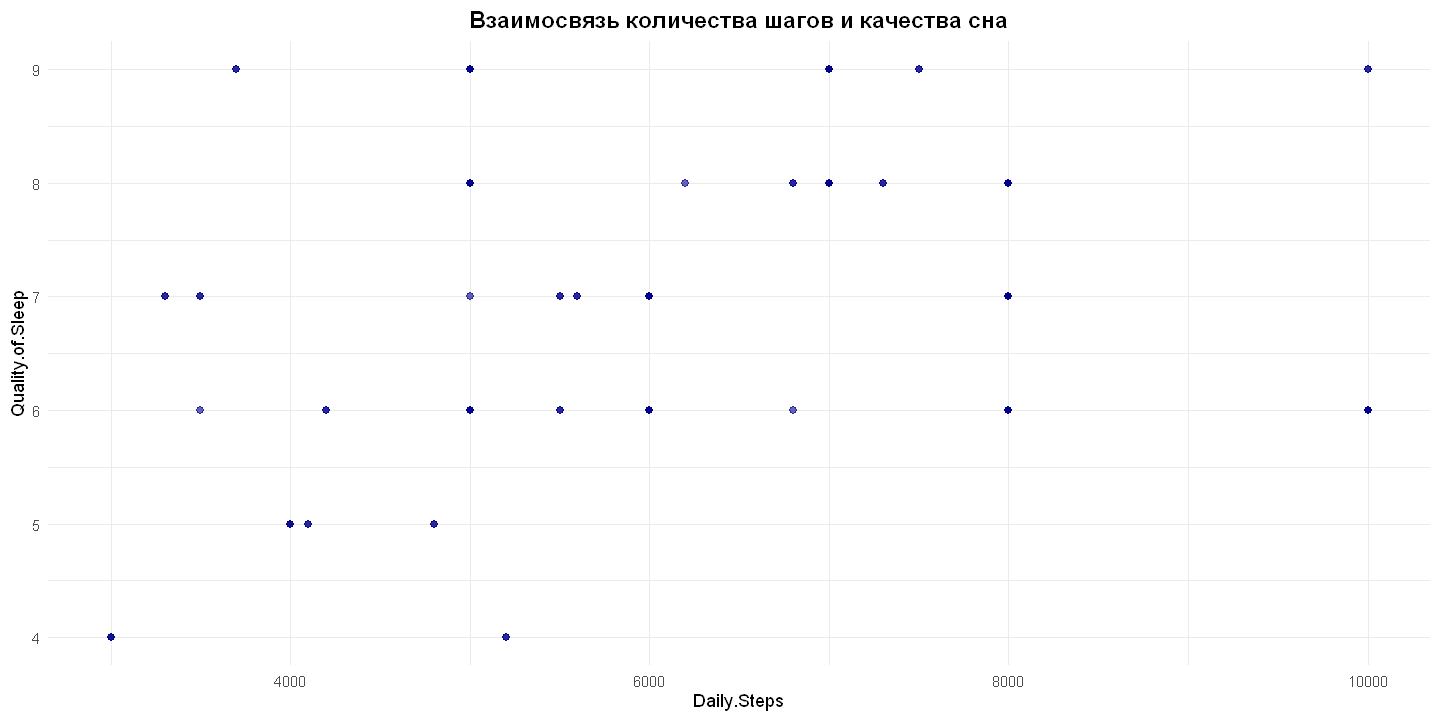

In [212]:
ggplot(df, aes(x = Daily.Steps, y = Quality.of.Sleep)) + 
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  theme_minimal() +
  labs(title = "Взаимосвязь количества шагов и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

ggsave("materials/scatterplot/daily_steps_quality_of_sleep_scatterplot.png", width = 12, height = 6, dpi = 300)

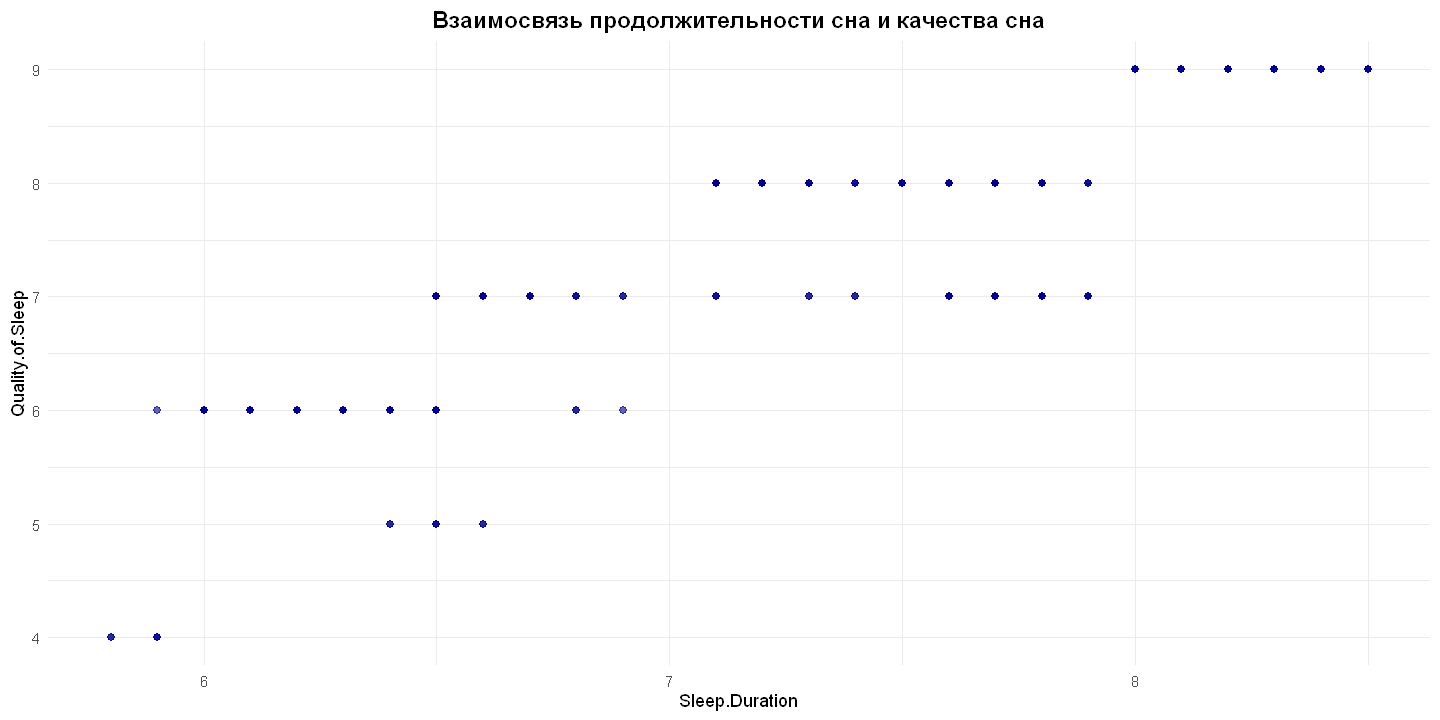

In [213]:
ggplot(df, aes(x =Sleep.Duration, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  theme_minimal() +
  labs(title = "Взаимосвязь продолжительности сна и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

ggsave("materials/scatterplot/sleep_duration_quality_of_sleep_scatterplot.png", width = 12, height = 6, dpi = 300)

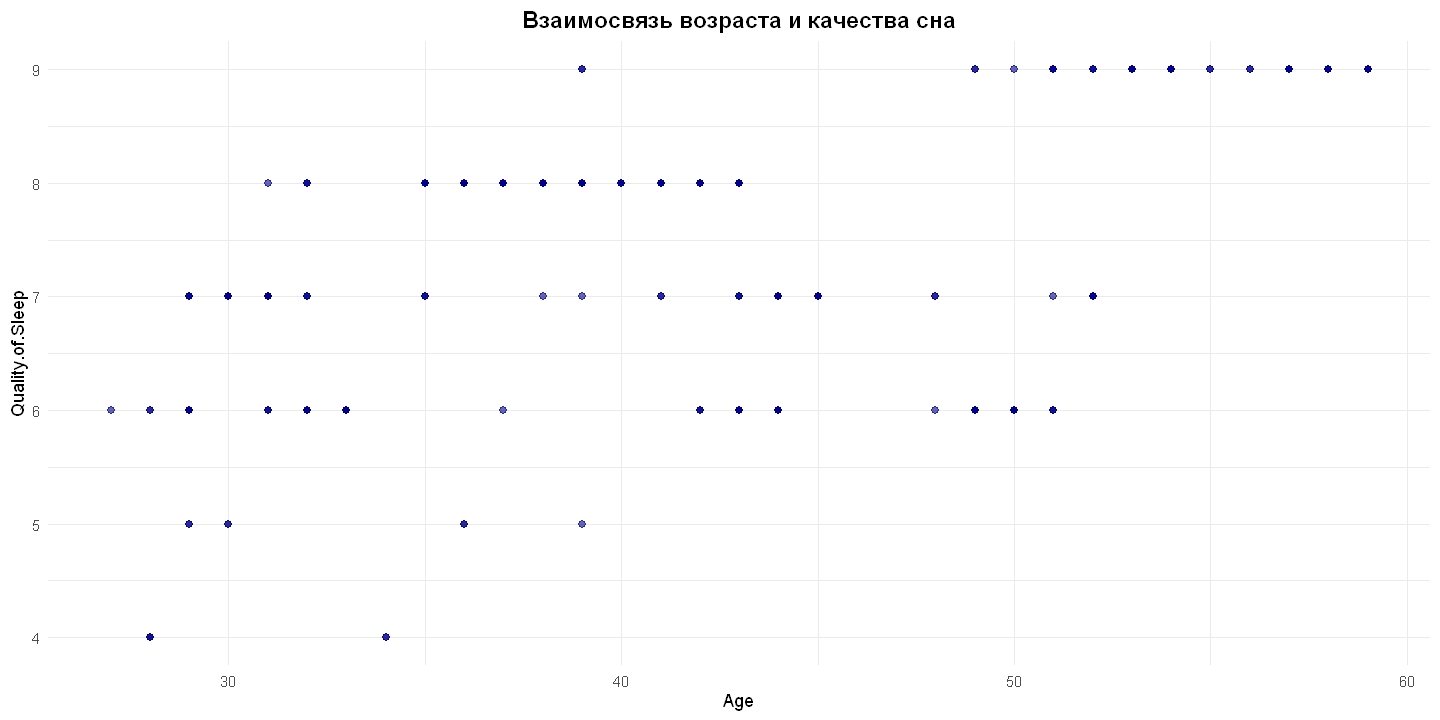

In [214]:
ggplot(df, aes(x = Age, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  theme_minimal() +
  labs(title = "Взаимосвязь возраста и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

ggsave("materials/scatterplot/age_quality_of_sleep_scatterplot.png", width = 12, height = 6, dpi = 300)

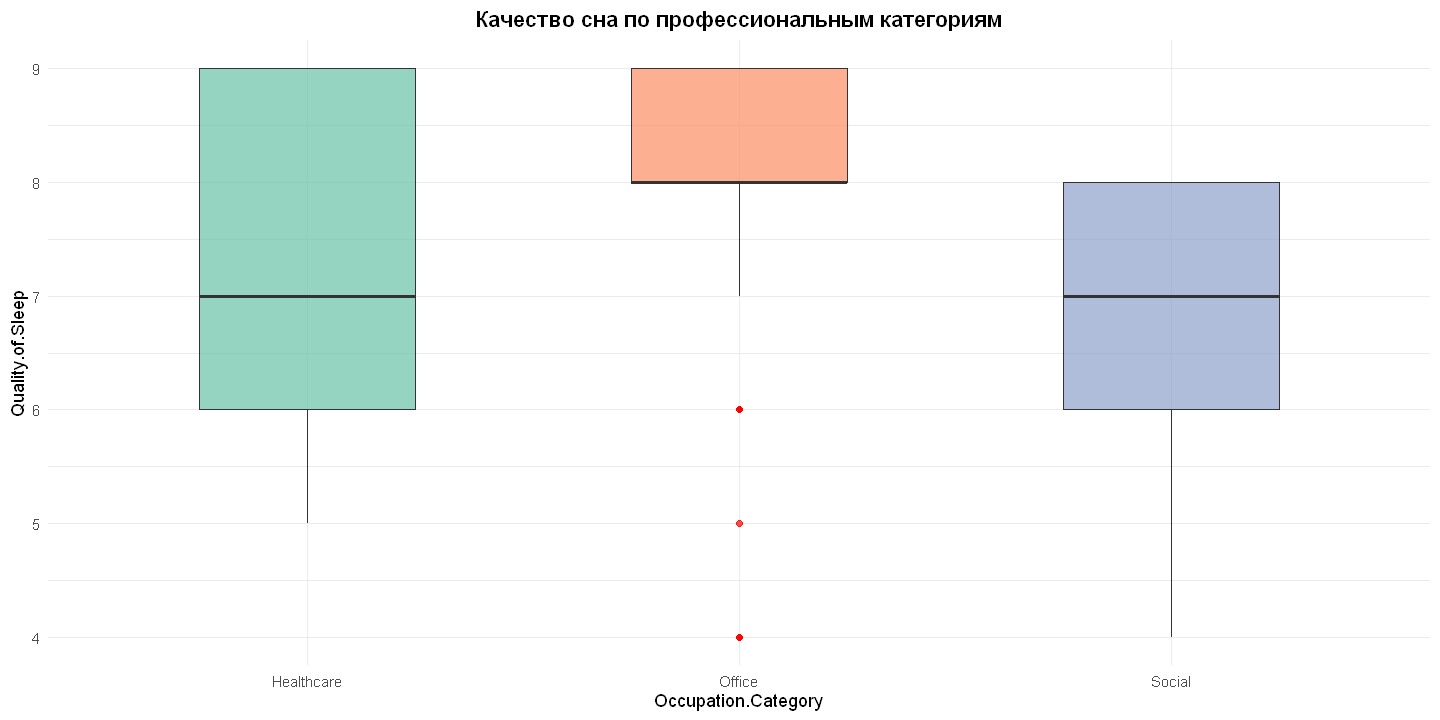

In [215]:
ggplot(df, aes(x = Occupation.Category, y = Quality.of.Sleep, fill = Occupation.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Качество сна по профессиональным категориям") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

ggsave("materials/boxplot/occupation_category_quality_of_sleep_boxplot.png", width = 12, height = 6, dpi = 300)

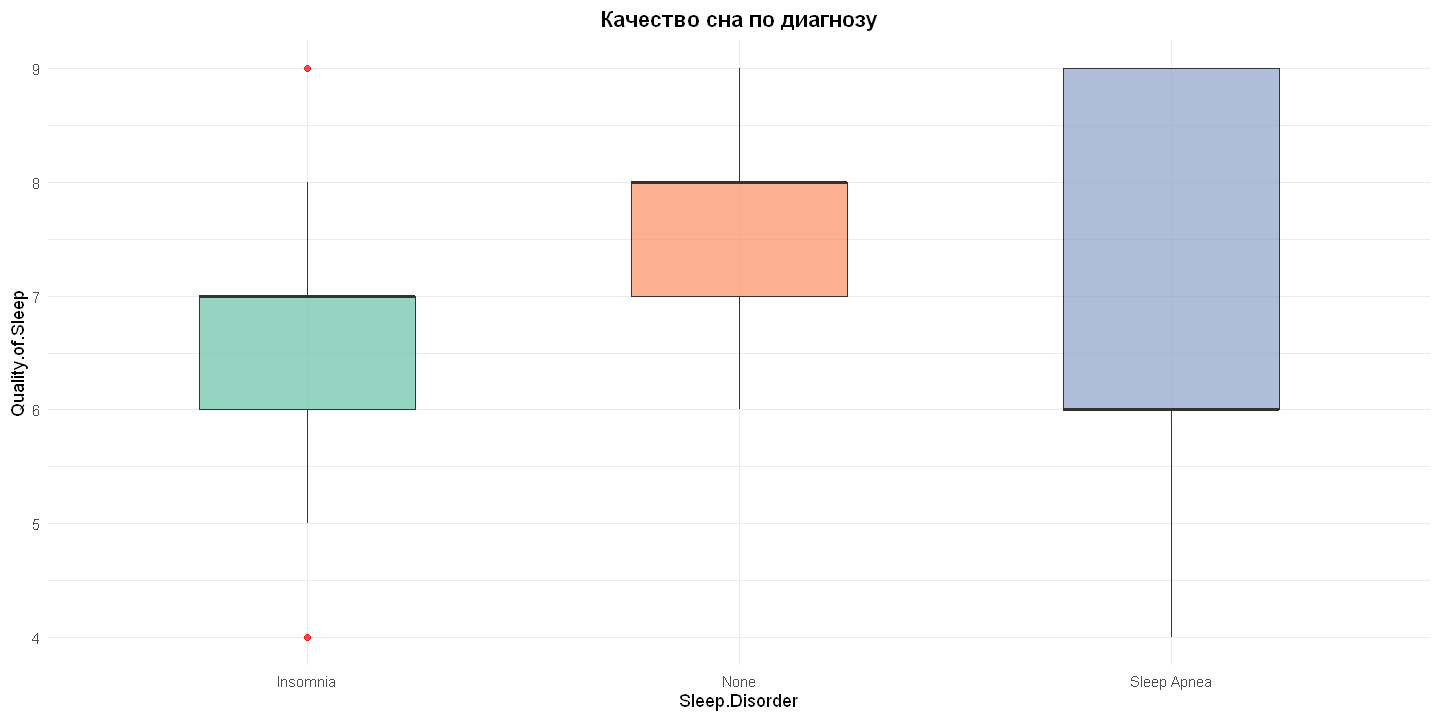

In [216]:
ggplot(df, aes(x = Sleep.Disorder, y = Quality.of.Sleep, fill = Sleep.Disorder)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Качество сна по диагнозу") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

ggsave("materials/boxplot/sleep_disorder_quality_of_sleep_boxplot.png", width = 12, height = 6, dpi = 300)

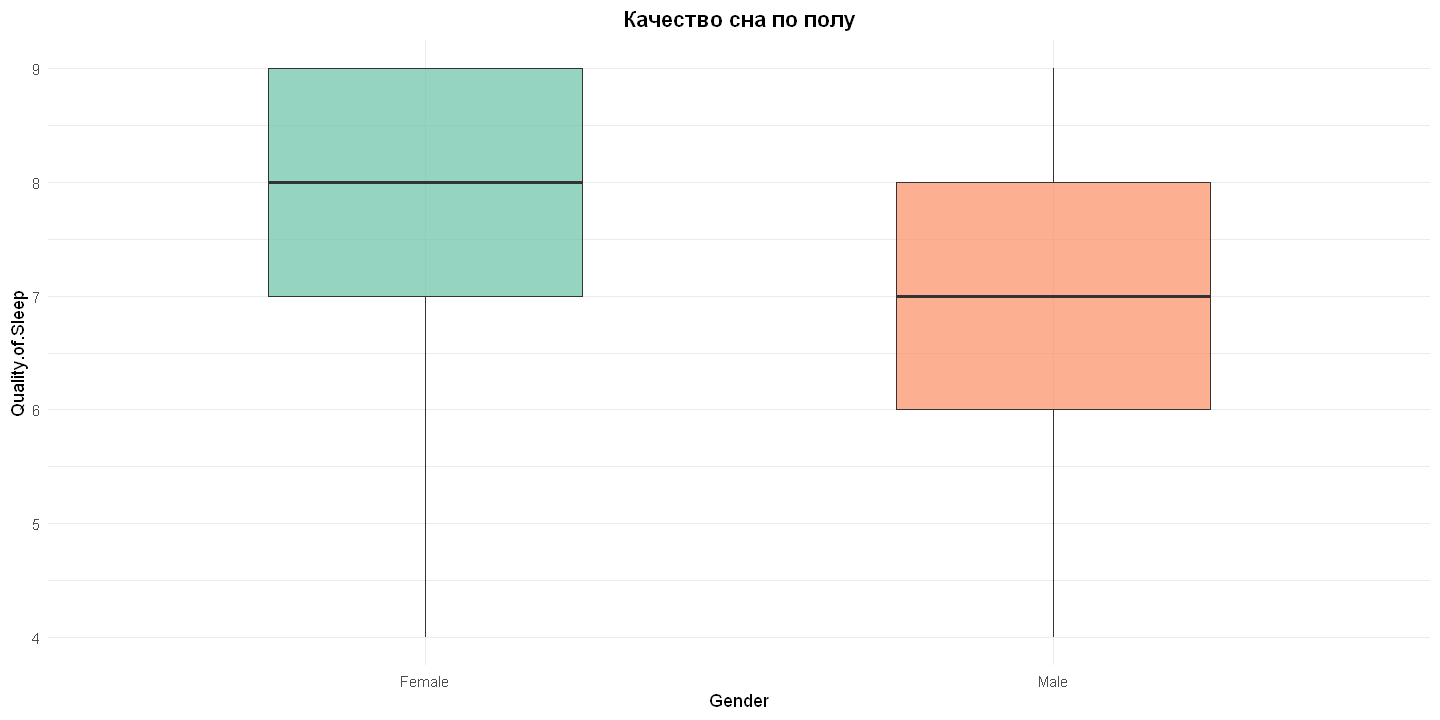

In [217]:
ggplot(df, aes(x = Gender, y = Quality.of.Sleep, fill = Gender)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Качество сна по полу") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

ggsave("materials/boxplot/gender_quality_of_sleep_boxplot.png", width = 12, height = 6, dpi = 300)

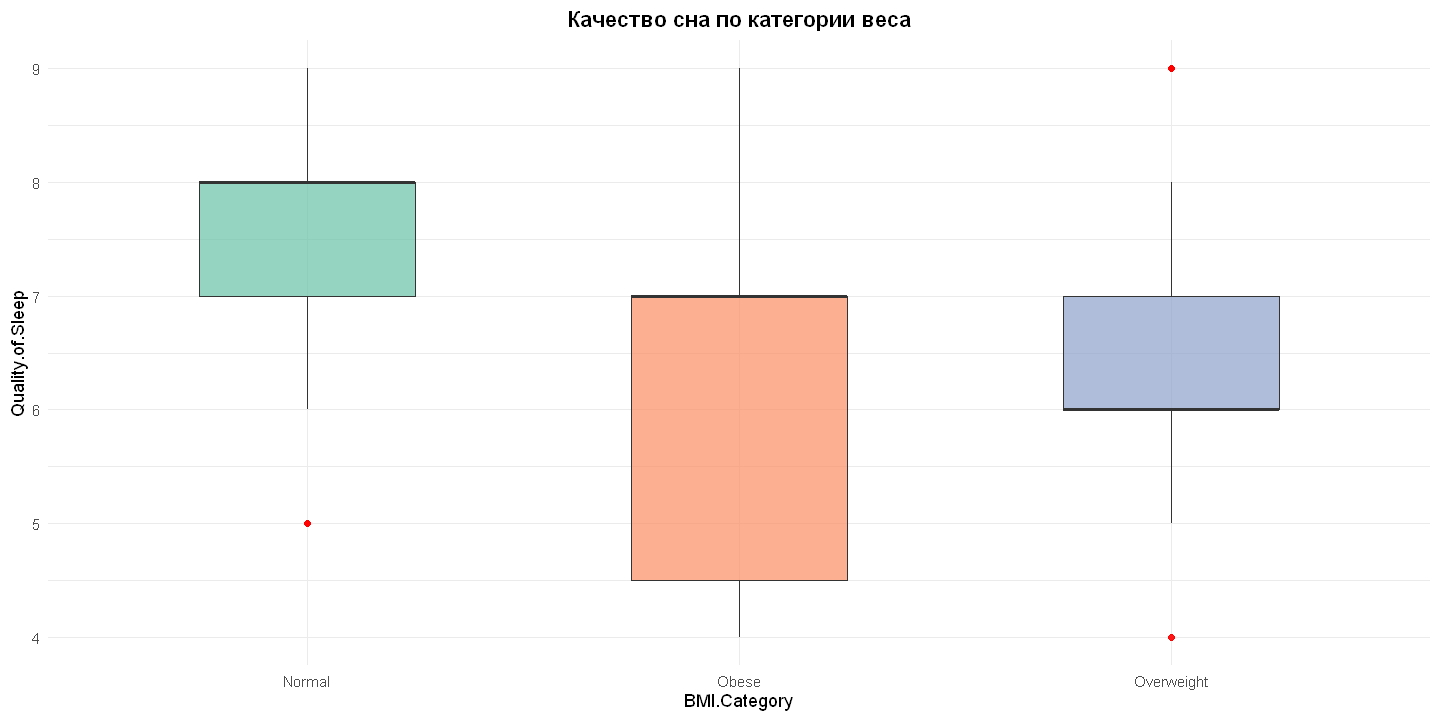

In [218]:
ggplot(df, aes(x = BMI.Category, y = Quality.of.Sleep, fill = BMI.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Качество сна по категории веса") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

ggsave("materials/boxplot/bmi_category_quality_of_sleep_boxplot.png", width = 12, height = 6, dpi = 300)